Execution steps:
1. Create a 3-regular graph G
2. Convert to QAOA circuit
3. Convert QAOA circuit to line graph representation LG
4. Find the best order with respect to contraction width with rgreedy algorithm
5. Plot of computational cost or contraction width
5. Contract LG with step-dependent slicing:
    1. Steps s before the peak
    2. Remove r vertices with the biggest number of neighbors
    3. Re-run ordering algorithm to find new contraction width
    4. Find optimal s
6. Graphs about computational cost or contraction width and benchmarking

In [1]:
import graph as g
import networkx as nx

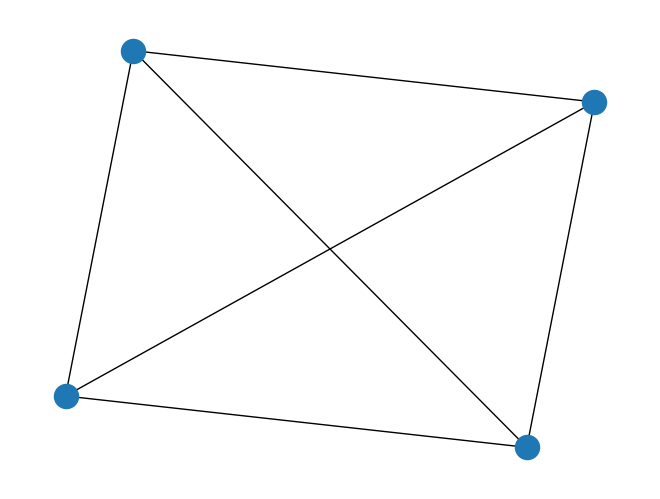

In [11]:
G = g.createGraph(4)
nx.draw(G)

In [12]:
circuit = g.createCircuit(G)
circuit.draw('mpl')
print(f"H gates: {circuit.count_ops()['h']}")
print(f"RZZ gates: {circuit.count_ops()['rzz']}")
print(f"RX gates: {circuit.count_ops()['rx']}")
print(f"Total gates: {sum(circuit.count_ops().values())}")

H gates: 4
RZZ gates: 6
RX gates: 4
Total gates: 14


Number of nodes: 24
Number of edges: 44


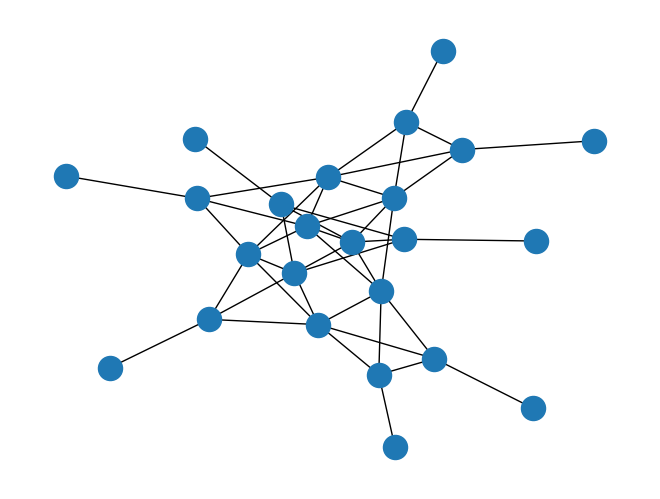

In [5]:
LG = g.convertToLineGraph(circuit)
nx.draw(LG)
print(f"Number of nodes: {LG.number_of_nodes()}")
print(f"Number of edges: {LG.number_of_edges()}")

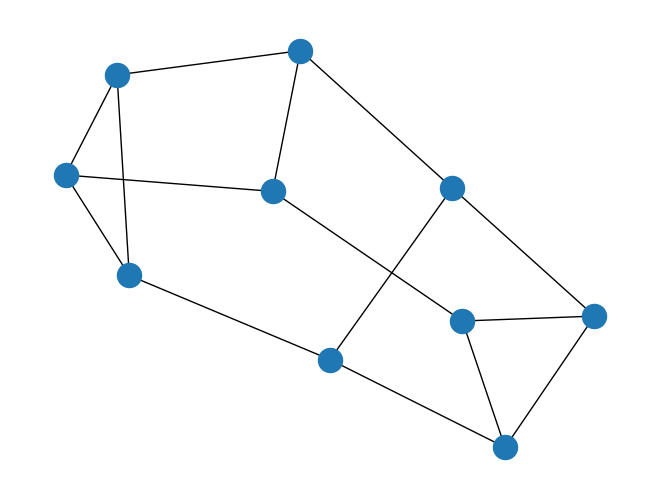

In [6]:
G = g.createGraph(10)
nx.draw(G)


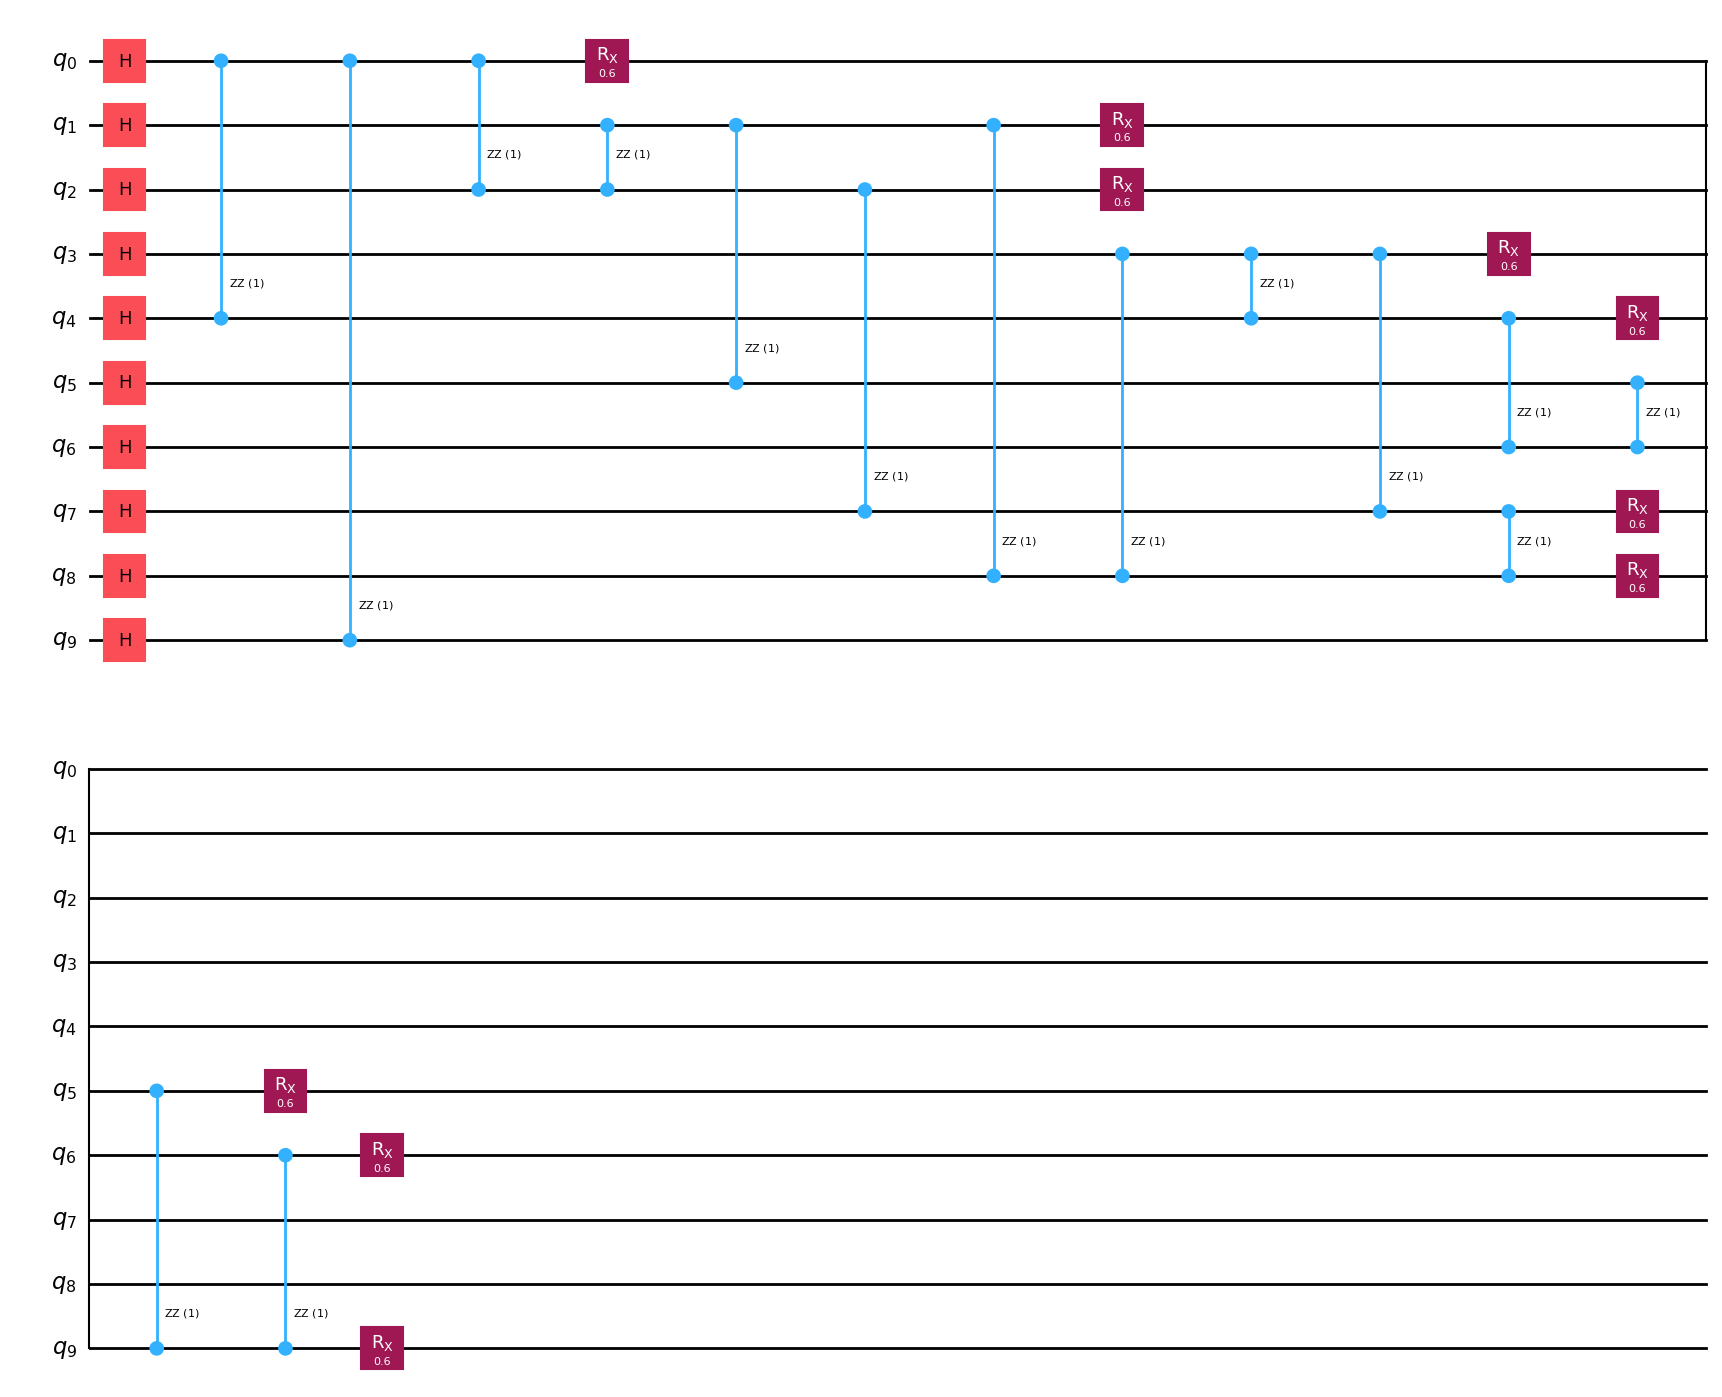

In [7]:
qc = g.createCircuit(G)
qc.draw('mpl')

Number of nodes: 60
Number of edges: 110


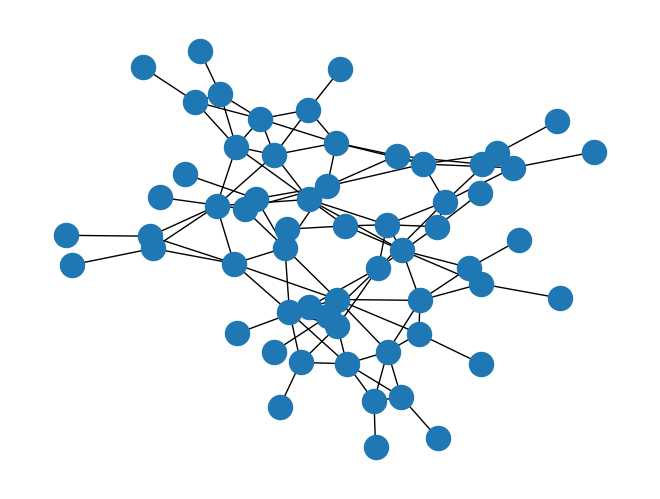

In [10]:
LG = g.convertToLineGraph(qc)
nx.draw(LG)
order, width, neighbors = g.rgreedy(LG, 0.5, 25)
print(f"Number of nodes: {LG.number_of_nodes()}")
print(f"Number of edges: {LG.number_of_edges()}")

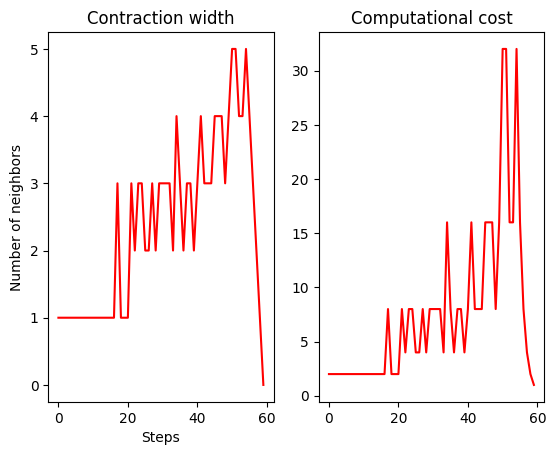

In [9]:
g.plotNeighbors(neighbors)

Contraction width was 18 now it's 16 with optimal step S = 48
Computational cost was 262144.0, now it's 65536.0 which is a reduction of 4.0


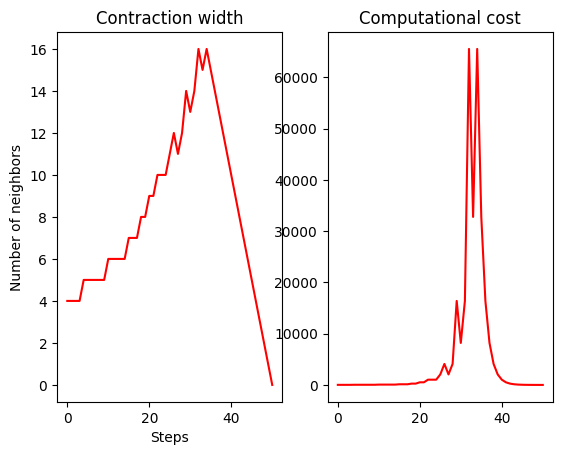

In [5]:
newOrder, newCWidth, newWidths, optimalS, toSlice = g.findOptimalS(G, neighbors, order)
print(f"Contraction width was {width} now it's {newCWidth} with optimal step S = {optimalS}")
print(f"Computational cost was {g.getCost(width)}, now it's {g.getCost(newCWidth)} which is a reduction of {g.getCost(width)/g.getCost(newCWidth)}")
g.plotNeighbors(newWidths)

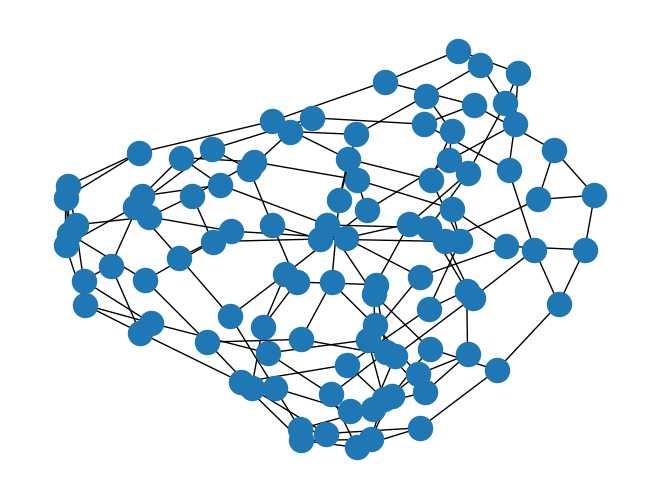

In [6]:
G = g.createGraph(100)
nx.draw(G)
order, width, neighbors = g.greedy(G)

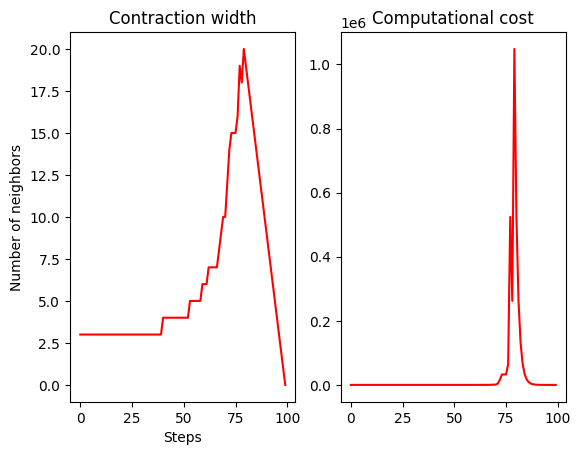

Contraction width c = 20, computational cost = 1048576.0


In [7]:
g.plotNeighbors(neighbors)
print(f"Contraction width c = {width}, computational cost = {g.getCost(width)}")